In [1]:
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import numpy as np, time, os
from collections import Counter
import matplotlib.pyplot as plt

In [2]:
# Repro / device
def set_seed(seed=123):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(123)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cpu')

In [46]:
@torch.no_grad()
def bipolar_sign(x: torch.Tensor) -> torch.Tensor:
    # We map to {-1,+1}; ties go to +1 for determinism.
    return torch.where(x >= 0, torch.ones_like(x), -torch.ones_like(x))

def _rand_bip(shape, device=None):
    device = device or DEVICE
    r = torch.randint(0, 2, shape, device=device, dtype=torch.int8)
    return r.float().mul_(2).sub_(1)  # {0,1} -> {-1,+1}

def make_position_hvs(n_positions: int, dim: int, device=None) -> torch.Tensor:
    # We assign each pixel position a random bipolar hypervector.
    return _rand_bip((n_positions, dim), device=device or DEVICE)

@torch.no_grad()
def encode_binary_images_to_hvs(imgs: torch.Tensor,
                                pos_hvs: torch.Tensor,
                                threshold: float = 0.5) -> torch.Tensor:
    # Strategy: binarize -> flatten -> sum position HVs for '1' pixels -> majority sign.
    B, C, H, W = imgs.shape
    assert C == 1
    P = H * W
    x = (imgs.view(B, P) >= threshold).to(torch.float32).to(pos_hvs.device)  # [B,P], {0,1}
    hv = x @ pos_hvs                                                            # [B,D]
    return bipolar_sign(hv)

@torch.no_grad()
def build_class_prototypes(enc_loader: DataLoader,
                           pos_hvs: torch.Tensor,
                           n_classes: int = 10,
                           threshold: float = 0.5) -> torch.Tensor:
    # We bundle all sample HVs per class and sign to get one prototype per class.
    D = pos_hvs.shape[1]
    accum = torch.zeros((n_classes, D), device=pos_hvs.device, dtype=torch.float32)
    for imgs, labels in enc_loader:
        imgs   = imgs.to(pos_hvs.device, non_blocking=True)
        labels = labels.to(pos_hvs.device, non_blocking=True)
        hvs = encode_binary_images_to_hvs(imgs, pos_hvs, threshold=threshold)
        for c in range(n_classes):
            m = (labels == c)
            if m.any():
                accum[c] += hvs[m].sum(dim=0)
    return bipolar_sign(accum)

@torch.no_grad()
def cosine_sim(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    a32 = a.float(); b32 = b.float()
    an = torch.linalg.norm(a32, dim=1, keepdim=True).clamp_min_(1e-8)
    bn = torch.linalg.norm(b32, dim=1, keepdim=True).clamp_min_(1e-8).T
    return (a32 @ b32.T) / (an * bn)

@torch.no_grad()
def predict_with_prototypes(imgs: torch.Tensor,
                            pos_hvs: torch.Tensor,
                            prototypes: torch.Tensor,
                            threshold: float = 0.5) -> torch.Tensor:
    hvs = encode_binary_images_to_hvs(imgs, pos_hvs, threshold=threshold)
    sims = cosine_sim(hvs, prototypes)
    return sims.argmax(dim=1)

@torch.no_grad()
def evaluate_loader(data_loader: DataLoader,
                    pos_hvs: torch.Tensor,
                    prototypes: torch.Tensor,
                    threshold: float = 0.5) -> float:
    correct = total = 0
    for imgs, labels in data_loader:
        imgs   = imgs.to(pos_hvs.device, non_blocking=True)
        labels = labels.to(pos_hvs.device, non_blocking=True)
        preds = predict_with_prototypes(imgs, pos_hvs, prototypes, threshold=threshold)
        correct += (preds == labels).sum().item()
        total   += labels.numel()
    return 100.0 * correct / total

# HDC

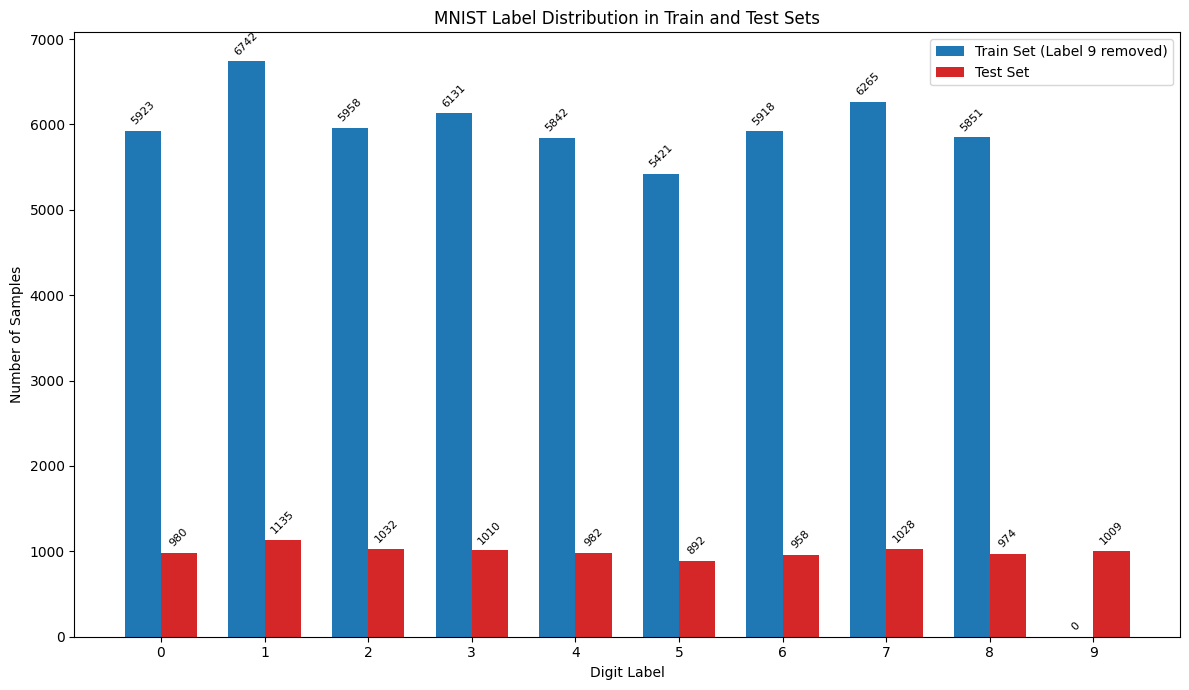

In [55]:
from torch.utils.data import Subset

transform = transforms.ToTensor()

# --- Load the (filtered) dataset ---
full_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
labels_to_remove = [9]  # example
indices = [i for i, (_, label) in enumerate(full_dataset) if label not in labels_to_remove]
train_ds = Subset(full_dataset, indices)
test_ds = datasets.MNIST(root="/content/data", train=False, download=True, transform=transform)

# --- Count the Label Distributions ---
train_label_distribution = Counter(train_ds.dataset.targets[train_ds.indices].numpy())
test_label_distribution = Counter(test_ds.targets.numpy())

labels = sorted(test_label_distribution.keys()) # Should be [0, 1, ..., 9]
train_counts = [train_label_distribution.get(label, 0) for label in labels] # Use .get() to handle the missing label 9
test_counts = [test_label_distribution[label] for label in labels]

x = np.arange(len(labels))  # The label locations on the x-axis
width = 0.35  # The width of the bars

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, train_counts, width, label='Train Set (Label 9 removed)', color='tab:blue')
rects2 = ax.bar(x + width/2, test_counts, width, label='Test Set', color='tab:red')

ax.set_ylabel('Number of Samples')
ax.set_xlabel('Digit Label')
ax.set_title('MNIST Label Distribution in Train and Test Sets')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, padding=3, rotation=45, fontsize=8)
ax.bar_label(rects2, padding=3, rotation=45, fontsize=8)

fig.tight_layout()
plt.show()

In [49]:
BATCH_SIZE = 512

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=False)

In [50]:
DIM = 10_000  # We typically use 8k–20k; 10k is a solid default.
H, W = 28, 28
P = H * W

pos_hvs = make_position_hvs(P, DIM, device=DEVICE)
pos_hvs.shape, pos_hvs.device

(torch.Size([784, 10000]), device(type='cpu'))

In [69]:
t0 = time.time()
prototypes = build_class_prototypes(train_loader, pos_hvs, n_classes=9, threshold=0.5)
print("Prototypes:", prototypes.shape, "built in %.2fs" % (time.time() - t0))

Prototypes: torch.Size([9, 10000]) built in 7.23s


In [70]:
acc = evaluate_loader(test_loader, pos_hvs, prototypes, threshold=0.5)
print(f"Test accuracy (MNIST): {acc:.2f}%")

Test accuracy (MNIST): 74.89%


# ConformalHDC

In [93]:
# --- Load the (filtered) dataset ---
generator = torch.Generator().manual_seed(0)

full_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
labels_to_remove = [9]  # example
indices = [i for i, (_, label) in enumerate(full_dataset) if label not in labels_to_remove]
filtered_ds = Subset(full_dataset, indices)

train_size = int(0.8 * len(filtered_ds))
calib_size = len(filtered_ds) - train_size
train_ds, calib_ds = random_split(filtered_ds, [train_size, calib_size])
test_ds = datasets.MNIST(root="/content/data", train=False, download=True, transform=transform)

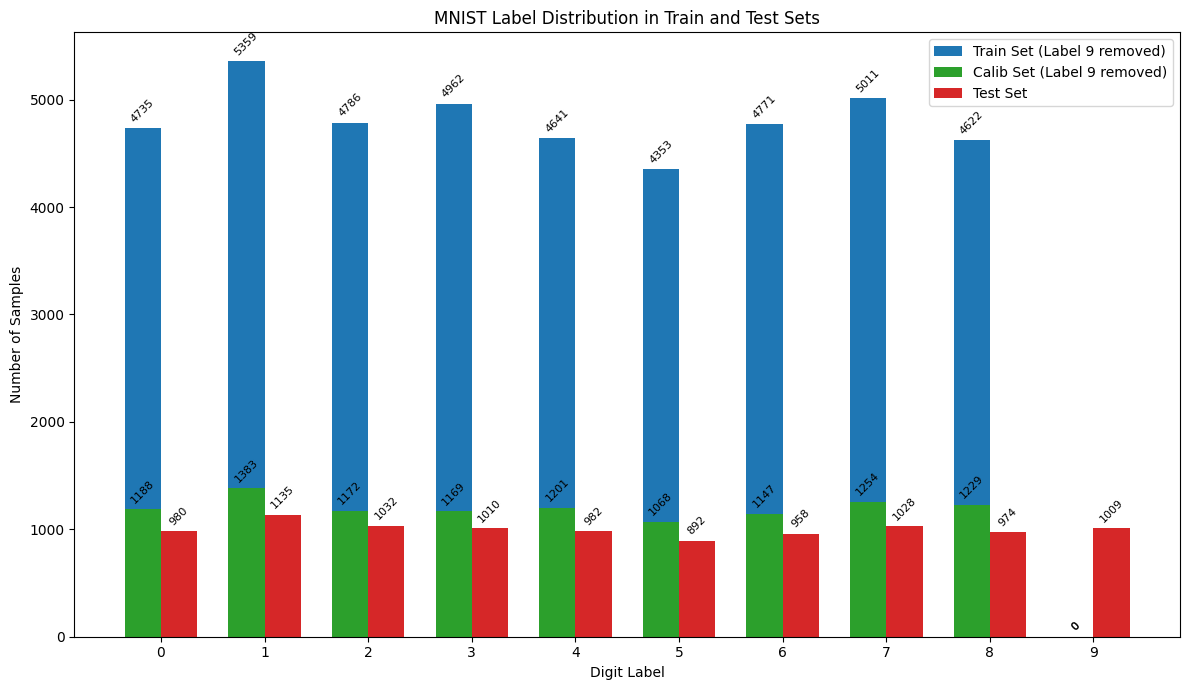

In [103]:
# --- Count the Label Distributions ---
train_label_distribution = Counter(train_ds.dataset.dataset.targets[[filtered_ds.indices[i] for i in train_ds.indices]].numpy())
calib_label_distribution = Counter(train_ds.dataset.dataset.targets[[filtered_ds.indices[i] for i in calib_ds.indices]].numpy())
test_label_distribution = Counter(test_ds.targets.numpy())

labels = sorted(test_label_distribution.keys()) # Should be [0, 1, ..., 9]
train_counts = [train_label_distribution.get(label, 0) for label in labels] # Use .get() to handle the missing label 9
calib_counts = [calib_label_distribution.get(label, 0) for label in labels] # Use .get() to handle the missing label 9
test_counts = [test_label_distribution[label] for label in labels]

x = np.arange(len(labels))  # The label locations on the x-axis
width = 0.35  # The width of the bars

fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, train_counts, width, label='Train Set (Label 9 removed)', color='tab:blue')
rects2 = ax.bar(x - width/2, calib_counts, width, label='Calib Set (Label 9 removed)', color='tab:green')
rects3 = ax.bar(x + width/2, test_counts, width, label='Test Set', color='tab:red')

ax.set_ylabel('Number of Samples')
ax.set_xlabel('Digit Label')
ax.set_title('MNIST Label Distribution in Train and Test Sets')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

ax.bar_label(rects1, padding=3, rotation=45, fontsize=8)
ax.bar_label(rects2, padding=3, rotation=45, fontsize=8)
ax.bar_label(rects3, padding=3, rotation=45, fontsize=8)

fig.tight_layout()
plt.show()